In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

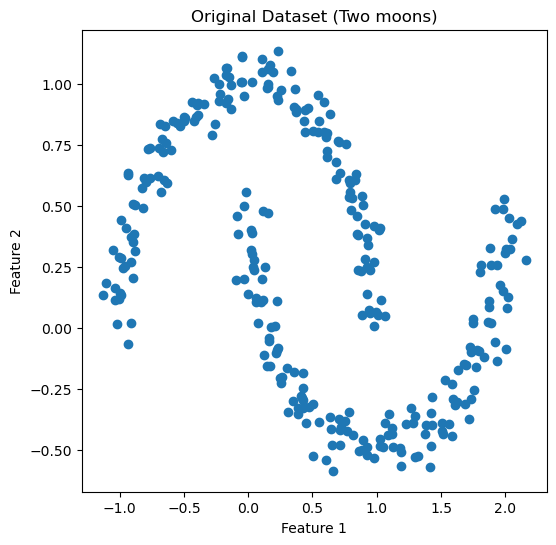

In [2]:
X, y = make_moons(n_samples=300, noise=0.06, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Dataset (Two moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

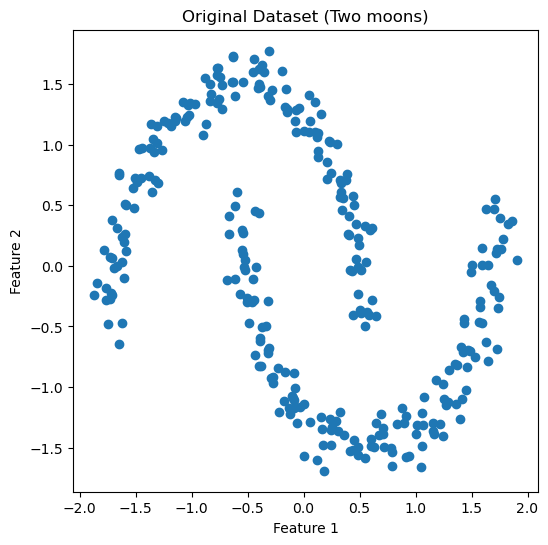

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(6, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.title("Original Dataset (Two moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [26]:
dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

In [27]:
db_labels = dbscan.fit_predict(X_scaled)

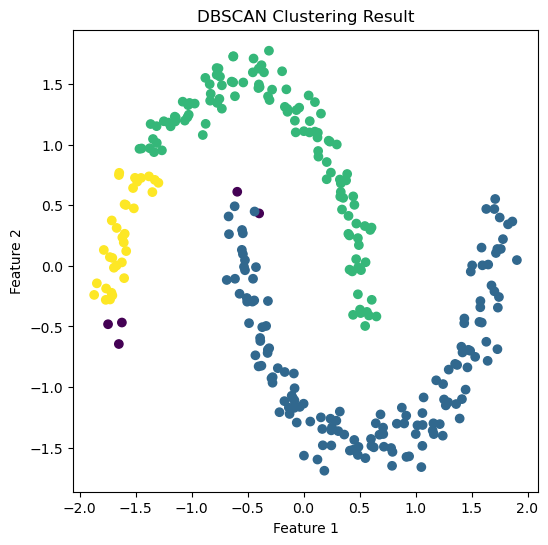

Unique Cluster labels:  [-1  0  1  2]


In [28]:
plt.figure(figsize=(6,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c = db_labels, cmap="viridis")
plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Unique Cluster labels: ", np.unique(db_labels))

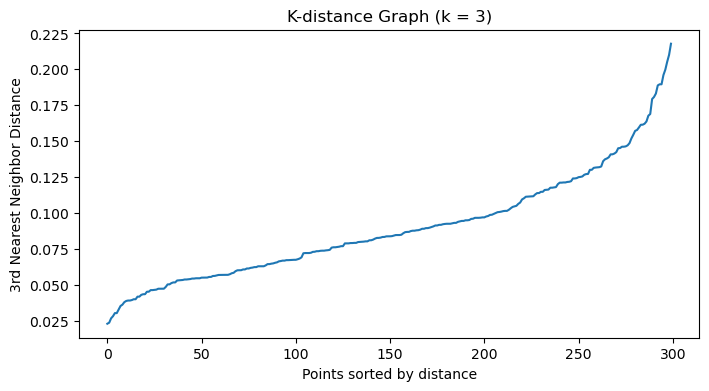

In [29]:
# Choosing eps using k-distance plot

neighbors = NearestNeighbors(
    n_neighbors=3
)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 2])

plt.figure(figsize=(8, 4))

plt.plot(distances)
plt.title("K-distance Graph (k = 3)")
plt.xlabel("Points sorted by distance")
plt.ylabel("3rd Nearest Neighbor Distance")
plt.show() 


In [33]:
cluster = 3 

In [34]:
# hierarchical clustering Implementation 
hc = AgglomerativeClustering(
    n_clusters=cluster,
    linkage='ward',
)

hc_labels = hc.fit_predict(X_scaled)

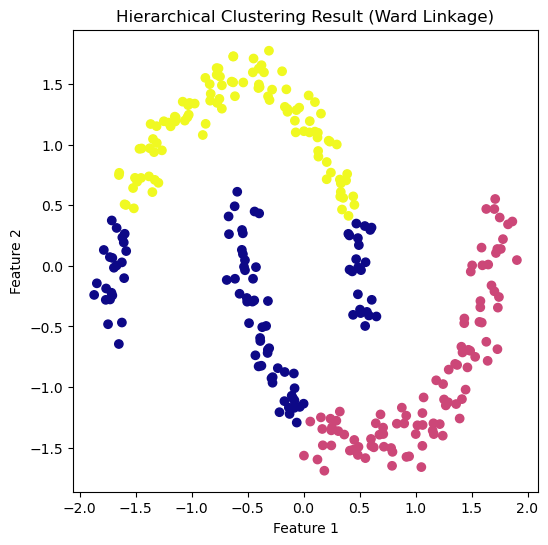

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c = hc_labels, cmap='plasma')
plt.title("Hierarchical Clustering Result (Ward Linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

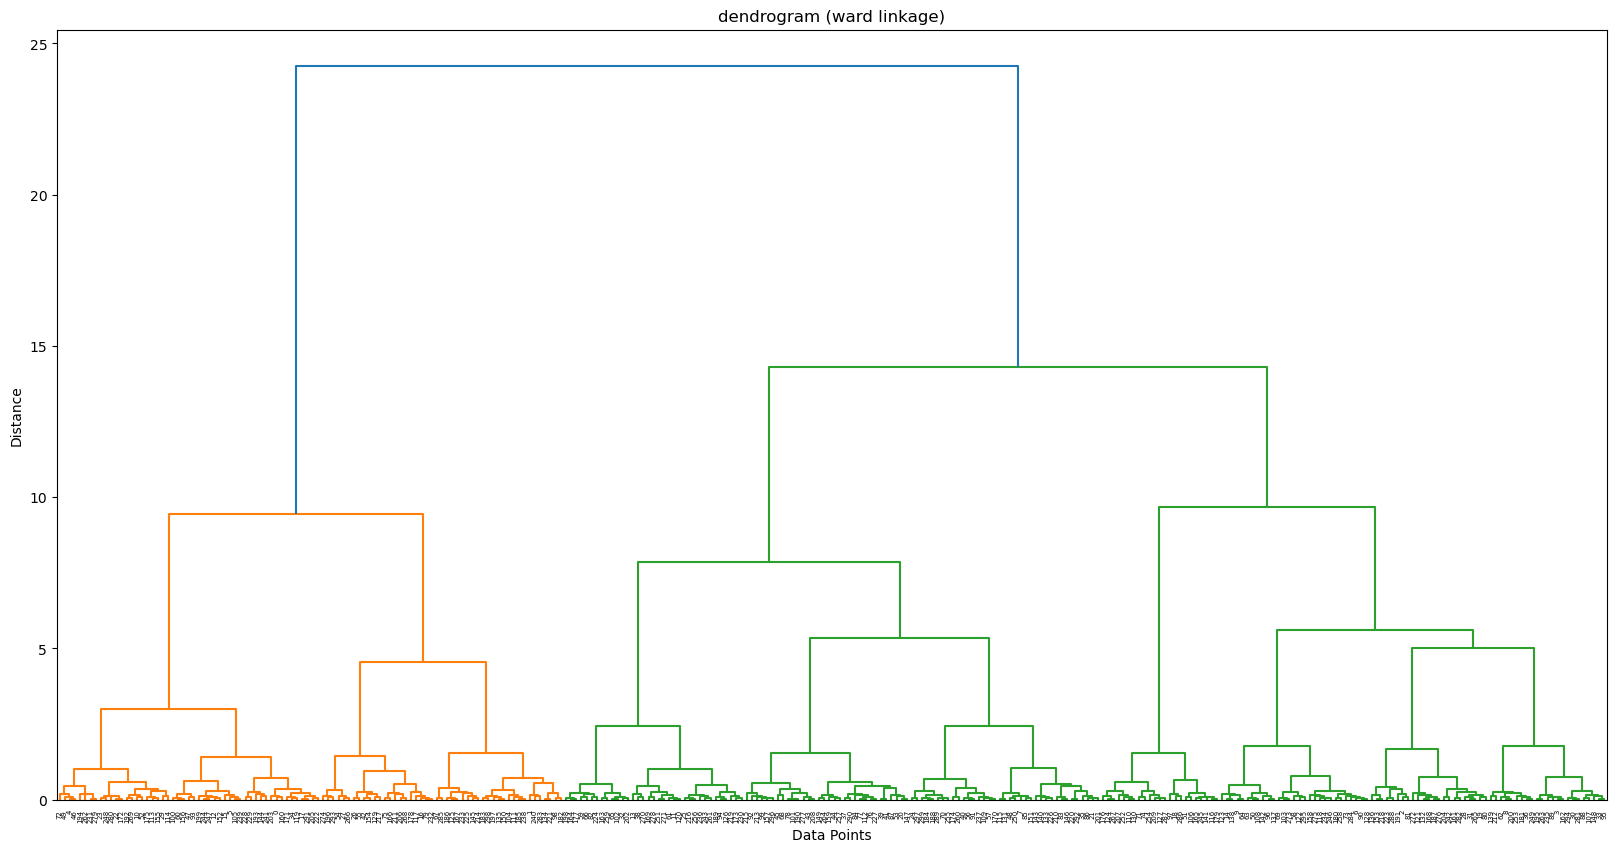

In [36]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(20, 10))
dendrogram(linked)

plt.title("dendrogram (ward linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()  

**Interpreting the Dendogram**

- Height of merge indicates distance
- Horizontal cut decides cluster count
- Allows flexibility in cluster selection 